# 极坐标 SNO：Function Encoder 训练

本 Notebook 只训练 Function Encoder（FE），暂不训练 Transformer。

FE 学习

$[
P(\hat\theta,\hat r)\leftrightarrow z_P,
\qquad
f(\hat\theta,\hat r)\leftrightarrow z_f,
]$

其中 trunk 内部使用周期特征 \($[\sin\theta,\cos\theta,\hat r]$\)。


## 1. GPU 环境（必须在导入 JAX 前执行）

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # 按机器修改
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"


依赖缺失时，在对应虚拟环境安装：

```bash
pip install flax optax scipy matplotlib
```

GPU 版 JAX 请按本机 CUDA 版本安装，不要覆盖已经配置好的 JAX 环境。


## 2. 导入代码

In [2]:
from pathlib import Path
import sys
import time
import json
from dataclasses import asdict

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import serialization

# 改为 polar_annulus_sno 代码目录；若 Notebook 就放在该目录，可使用 Path.cwd()。
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "config_polar.py").exists():
    PROJECT_DIR = Path("/path/to/polar_annulus_sno")  # 必须修改

if not (PROJECT_DIR / "config_polar.py").exists():
    raise FileNotFoundError("请将 PROJECT_DIR 改为包含 config_polar.py 的代码目录。")

sys.path.insert(0, str(PROJECT_DIR))

from config_polar import PolarAnnulusConfig
from data_polar import (
    build_batch_pool,
    build_field_normalizer_from_batches,
    denormalize_f,
    denormalize_p,
    make_theta,
    normalize_f,
    normalize_p,
    outer_boundary_coords,
    sample_batch,
)
from models_polar import FunctionEncoder
from train_polar import (
    create_fe_state,
    fe_eval_step,
    fe_train_step,
    relative_l2,
    save_normalizer,
    save_params,
    train_fe,
)

print("JAX devices:", jax.devices())
print("Project directory:", PROJECT_DIR)


JAX devices: [CudaDevice(id=0)]
Project directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code


## 3. 配置

先运行 `smoke` 模式。流程无误后改成 `full`。配置类是冻结 dataclass，参数必须在构造时传入，不能用 `cfg.xxx = ...` 修改。


In [3]:
RUN_MODE = "full"  # "smoke" 或 "full"

if RUN_MODE == "smoke":
    cfg = PolarAnnulusConfig(
        r_inner=0.2, r_outer=1.0,
        k_min=0.2, k_max=2.0,
        prior_scale_pairs=((3.0, 3.0),),
        repeats_per_scale=1,
        sample_size=2,
        hidden_bnn=32,
        theta_size=16,
        radial_size=8,
        random_probe_points=16,
        normalizer_batches=2,
        n_basis=16,
        trunk_width=32,
        trunk_depth=3,
        fe_phys_weight=0.0,
        fe_physics_points=4,
        cnn_channels=(8, 16, 32),
        cnn_kernel_size=(3, 5),
        cnn_stride=(1, 2),
        cnn_dense_width=64,
        transformer_dim=32,
        transformer_heads=4,
        transformer_layers=2,
        transformer_mlp_dim=64,
        seq_chunks=4,
        cond_chunks=4,
        fe_steps=5,
        fe_lr=1.0e-3,
        pool_size=2,
        seed=0,
        out_dir=str(PROJECT_DIR / "out_polar_annulus_sno"),
        run_name="fe_smoke_test",
    )
else:
    cfg = PolarAnnulusConfig(
        r_inner=0.2, r_outer=1.0,
        k_min=1.0, k_max=1.0,
        prior_scale_pairs=((3.0, 3.0), (5.0, 5.0), (7.0, 7.0)),
        repeats_per_scale=1,
        sample_size=256,
        hidden_bnn=256,
        theta_size=128,
        radial_size=32,
        random_probe_points=1024,
        normalizer_batches=100,
        n_basis=512,
        trunk_width=512,
        trunk_depth=5,
        fe_phys_weight=0.0,
        fe_physics_points=128,
        cnn_channels=(32, 64, 128),
        cnn_kernel_size=(3, 5),
        cnn_stride=(1, 2),
        cnn_dense_width=1024,
        transformer_dim=512,
        transformer_heads=8,
        transformer_layers=4,
        transformer_mlp_dim=2048,
        seq_chunks=32,
        cond_chunks=32,
        fe_steps=500_000,
        fe_lr=1.0e-3,
        fe_b1=0.5,
        fe_b2=0.9,
        weight_decay=1.0e-6,
        pool_size=10,
        seed=0,
        out_dir=str(PROJECT_DIR / "out_polar_annulus_sno"),
        run_name="polar_v1",
    )

cfg.save_json()
print(json.dumps(asdict(cfg), indent=2))
print("Output directory:", cfg.output_dir)
print("Effective batch size:", cfg.effective_batch_size)
print("POD points:", cfg.n_pod)


{
  "r_inner": 0.2,
  "r_outer": 1.0,
  "k_min": 1.0,
  "k_max": 1.0,
  "prior_scale_pairs": [
    [
      3.0,
      3.0
    ],
    [
      5.0,
      5.0
    ],
    [
      7.0,
      7.0
    ]
  ],
  "repeats_per_scale": 1,
  "sample_size": 256,
  "hidden_bnn": 256,
  "bnn_bias_sigma": 1.0,
  "bnn_output_sigma": 1.0,
  "theta_size": 128,
  "radial_size": 32,
  "random_probe_points": 1024,
  "normalizer_batches": 100,
  "normalizer_eps": 1e-06,
  "n_basis": 512,
  "trunk_width": 512,
  "trunk_depth": 5,
  "fe_phys_weight": 0.0,
  "fe_physics_points": 128,
  "cnn_channels": [
    32,
    64,
    128
  ],
  "cnn_kernel_size": [
    3,
    5
  ],
  "cnn_stride": [
    1,
    2
  ],
  "cnn_dense_width": 1024,
  "transformer_dim": 512,
  "transformer_heads": 8,
  "transformer_layers": 4,
  "transformer_mlp_dim": 2048,
  "seq_chunks": 32,
  "cond_chunks": 32,
  "fe_steps": 500000,
  "ol_steps": 200000,
  "fe_lr": 0.001,
  "ol_lr": 0.001,
  "weight_decay": 1e-06,
  "fe_b1": 0.5,
  "fe_b2": 

## 4. 检查一个 PI-sampler batch

In [4]:
key = jax.random.PRNGKey(cfg.seed)
key, key_batch = jax.random.split(key)
batch = sample_batch(key_batch, cfg)

for name, value in batch._asdict().items():
    print(f"{name:16s}: {value.shape}")
    assert bool(jnp.all(jnp.isfinite(value))), f"{name} contains NaN/Inf"

# 网格按 [Nr, Nt] 展平，最后 Nt 个点为 r=r_outer。
outer_slice = slice((cfg.radial_size - 1) * cfg.theta_size, cfg.radial_size * cfg.theta_size)
max_outer_p = float(jnp.max(jnp.abs(batch.p_pod[:, outer_slice])))
print(f"max |P(r_outer)| from prior = {max_outer_p:.3e}")


boundary_coords : (768, 128, 2)
boundary_flux   : (768, 128)
pod_coords      : (4096, 2)
probe_coords    : (1024, 2)
p_pod           : (768, 4096)
f_pod           : (768, 4096)
p_probe         : (768, 1024)
f_probe         : (768, 1024)
k_values        : (768,)
max |P(r_outer)| from prior = 0.000e+00


### 可视化一个样本

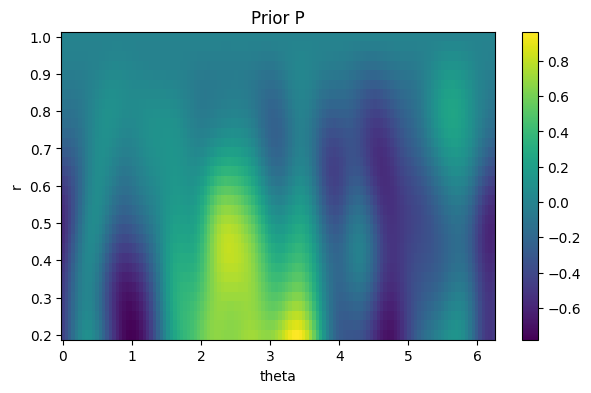

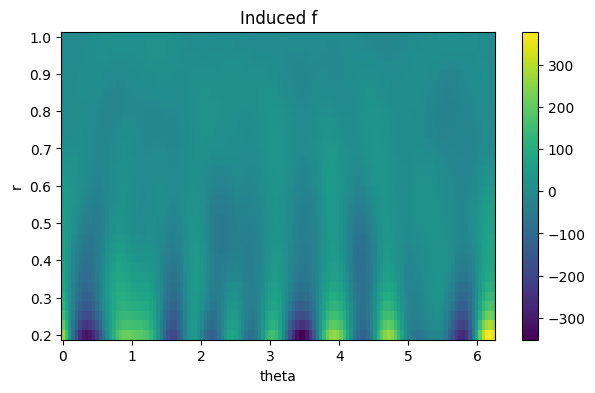

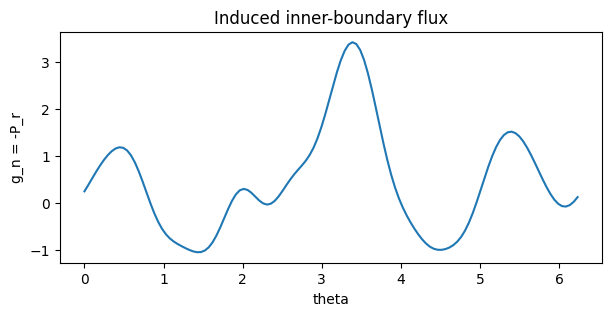

In [5]:
idx = 100
Nr, Nt = cfg.radial_size, cfg.theta_size
theta = np.asarray(make_theta(cfg))
radius = np.linspace(cfg.r_inner, cfg.r_outer, Nr)

p_grid = np.asarray(jax.device_get(batch.p_pod[idx])).reshape(Nr, Nt)
f_grid = np.asarray(jax.device_get(batch.f_pod[idx])).reshape(Nr, Nt)
flux = np.asarray(jax.device_get(batch.boundary_flux[idx]))

plt.figure(figsize=(7, 4))
plt.pcolormesh(theta, radius, p_grid, shading="auto")
plt.xlabel("theta")
plt.ylabel("r")
plt.title("Prior P")
plt.colorbar()
plt.show()

plt.figure(figsize=(7, 4))
plt.pcolormesh(theta, radius, f_grid, shading="auto")
plt.xlabel("theta")
plt.ylabel("r")
plt.title("Induced f")
plt.colorbar()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(theta, flux)
plt.xlabel("theta")
plt.ylabel("g_n = -P_r")
plt.title("Induced inner-boundary flux")
plt.show()


## 7. 训练 Function Encoder

In [ ]:
fe_state, normalizer = train_fe(cfg)

/home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/data_polar.py:460: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  p_sum_sq = jnp.asarray(0.0, dtype=jnp.float64)
/home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/data_polar.py:462: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  f_sum = jnp.asarray(0.0, dtype=jnp.float64)
/home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/data_polar.py:463: UserWarning: Explicitly requested dtype float64 requested in asarray is not av

[Normalizer] 计算完成： mean_p=0.000000e+00, std_p=2.718920e-01, mean_f=-2.725592e-03, std_f=1.427547e+02
[Normalizer] 已保存至：/home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v1


E0711 18:45:11.682908 3586517 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[4096,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0711 18:45:11.683006 3586517 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[4096,515]{1,0} parameter(0)
  parameter_1 = f32[515,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[4096,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0711 18:45:11.697962 3586507 x

[FE 0000000] loss=3.2167e+00 data=3.2167e+00 phys=0.0000e+00 RL2(P)=5.6803e+00 RL2(f)=1.2484e+01


## 8. 独立测试集重构与 MATLAB 导出

下面使用**独立随机种子**生成未参与训练的新样本，并在规则 `[Nr, Ntheta]` 网格上评估 Function Encoder 对压力场 `P` 和源项 `f` 的重构精度。

- 每个先验尺度默认生成 32 个样本，总样本数为 `len(prior_scale_pairs) × 32`。
- 重构按小批次执行，避免一次性处理完整测试集造成显存压力。
- 评估状态从磁盘上的最终 `fe_params.msgpack` 和归一化参数重新加载，不依赖训练单元仍保留在内存中的状态。
- 导出 `.mat` 中的场数组顺序统一为 `[sample, r, theta]`。

In [4]:
from dataclasses import replace
from scipy.io import savemat

from train_polar import load_normalizer

# 可以按显存和需要调整。默认 3 个先验尺度 × 32 = 96 个独立测试样本。
EVAL_SEED = cfg.seed + 20_260_712
EVAL_SAMPLES_PER_SCALE = 64
RECON_CHUNK_SIZE = 16

# 只改变采样批量，不改变网格、网络结构、先验尺度或 k 的分布。
eval_cfg = replace(
    cfg,
    sample_size=EVAL_SAMPLES_PER_SCALE,
    repeats_per_scale=1,
)

fe_checkpoint_path = cfg.output_dir / "fe_params.msgpack"
required_normalizer_files = [
    cfg.output_dir / "norm_mean_p.npy",
    cfg.output_dir / "norm_std_p.npy",
    cfg.output_dir / "norm_mean_f.npy",
    cfg.output_dir / "norm_std_f.npy",
]

if not fe_checkpoint_path.exists():
    raise FileNotFoundError(f"找不到 FE 权重：{fe_checkpoint_path}")
missing_normalizer_files = [p for p in required_normalizer_files if not p.exists()]
if missing_normalizer_files:
    raise FileNotFoundError(f"缺少归一化文件：{missing_normalizer_files}")

# 使用独立状态加载磁盘上的最终 checkpoint，避免覆盖训练变量 fe_state。
fe_eval_state, _ = create_fe_state(
    cfg,
    jax.random.PRNGKey(EVAL_SEED + 1),
)
loaded_fe_params = serialization.from_bytes(
    fe_eval_state.params,
    fe_checkpoint_path.read_bytes(),
)
fe_eval_state = fe_eval_state.replace(params=loaded_fe_params)
eval_normalizer = load_normalizer(cfg.output_dir)

export_dir = cfg.output_dir / "fe_reconstruction_test"
export_dir.mkdir(parents=True, exist_ok=True)

print("FE checkpoint:", fe_checkpoint_path)
print("Evaluation samples:", eval_cfg.effective_batch_size)
print("Reconstruction chunk size:", RECON_CHUNK_SIZE)
print("Export directory:", export_dir)

E0712 19:01:36.950140 3599911 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[4096,512]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["64","64"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0712 19:01:36.950246 3599911 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[4096,515]{1,0} parameter(0)
  parameter_1 = f32[515,512]{1,0} parameter(1)
  ROOT dot_general.0 = f32[4096,512]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["64"]}
}
E0712 19:01:36.964869 3599876 x

FE checkpoint: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v1/fe_params.msgpack
Evaluation samples: 192
Reconstruction chunk size: 16
Export directory: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v1/fe_reconstruction_test


### 8.1 生成独立样本并分块重构

编码器输入和重构输出都使用规则 POD 网格。真实场、重构场和潜变量会从 GPU 传回 CPU，以便后续统计和导出。

In [5]:
eval_batch = sample_batch(
    jax.random.PRNGKey(EVAL_SEED),
    eval_cfg,
)

eval_coords_hat = eval_batch.pod_coords

@jax.jit
def reconstruct_fe_chunk(params, p_values, f_values):
    p_latent = fe_eval_state.apply_fn(
        {"params": params},
        normalize_p(p_values, eval_normalizer),
        method=FunctionEncoder.encode_p,
    )
    f_latent = fe_eval_state.apply_fn(
        {"params": params},
        normalize_f(f_values, eval_normalizer),
        method=FunctionEncoder.encode_f,
    )

    p_recon_norm = fe_eval_state.apply_fn(
        {"params": params},
        p_latent,
        eval_coords_hat,
        method=FunctionEncoder.reconstruct_p,
    )
    f_recon_norm = fe_eval_state.apply_fn(
        {"params": params},
        f_latent,
        eval_coords_hat,
        method=FunctionEncoder.reconstruct_f,
    )

    return (
        denormalize_p(p_recon_norm, eval_normalizer),
        denormalize_f(f_recon_norm, eval_normalizer),
        p_latent,
        f_latent,
    )


p_recon_parts = []
f_recon_parts = []
z_p_parts = []
z_f_parts = []

n_eval_samples = eval_cfg.effective_batch_size
for start in range(0, n_eval_samples, RECON_CHUNK_SIZE):
    stop = min(start + RECON_CHUNK_SIZE, n_eval_samples)
    p_chunk, f_chunk, z_p_chunk, z_f_chunk = reconstruct_fe_chunk(
        fe_eval_state.params,
        eval_batch.p_pod[start:stop],
        eval_batch.f_pod[start:stop],
    )
    jax.block_until_ready(p_chunk)

    p_recon_parts.append(np.asarray(jax.device_get(p_chunk)))
    f_recon_parts.append(np.asarray(jax.device_get(f_chunk)))
    z_p_parts.append(np.asarray(jax.device_get(z_p_chunk)))
    z_f_parts.append(np.asarray(jax.device_get(z_f_chunk)))
    print(f"reconstructed {stop:4d} / {n_eval_samples}")

Nr, Nt = cfg.radial_size, cfg.theta_size
p_true = np.asarray(jax.device_get(eval_batch.p_pod)).reshape(n_eval_samples, Nr, Nt)
f_true = np.asarray(jax.device_get(eval_batch.f_pod)).reshape(n_eval_samples, Nr, Nt)
p_recon = np.concatenate(p_recon_parts, axis=0).reshape(n_eval_samples, Nr, Nt)
f_recon = np.concatenate(f_recon_parts, axis=0).reshape(n_eval_samples, Nr, Nt)
z_p = np.concatenate(z_p_parts, axis=0)
z_f = np.concatenate(z_f_parts, axis=0)

boundary_flux = np.asarray(jax.device_get(eval_batch.boundary_flux))
k_values_eval = np.asarray(jax.device_get(eval_batch.k_values))
coords_hat_eval = np.asarray(jax.device_get(eval_batch.pod_coords))
theta_eval = np.asarray(make_theta(cfg))
radius_eval = np.linspace(cfg.r_inner, cfg.r_outer, Nr, dtype=np.float32)

print("P/F field shape [sample, r, theta]:", p_true.shape)
print("z_P/z_f shape:", z_p.shape, z_f.shape)

E0712 19:03:39.481042 3599910 xtile_compiler.cc:399] Fusion: gemm_fusion_dot = f32[1024,4096]{0,1} fusion(concatenate.20, params__trunk____Dense_1____kernel__.1, params__trunk____Dense_2____kernel__.1), kind=kCustom, calls=gemm_fusion_dot_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["64","32"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0712 19:03:39.481309 3599910 xtile_compiler.cc:401] Computation: gemm_fusion_dot_computation.clone {
  parameter_1.3 = f32[515,512]{1,0} parameter(1)
  parameter_2.1 = f32[515,512]{1,0} parameter(2)
  concatenate.33 = f32[515,1024]{1,0} concatenate(parameter_1.3, parameter_2.1), dimensions={1}
  parameter_0.3 = f32[4096,515]{1,0} parameter

reconstructed   16 / 192
reconstructed   32 / 192
reconstructed   48 / 192
reconstructed   64 / 192
reconstructed   80 / 192
reconstructed   96 / 192
reconstructed  112 / 192
reconstructed  128 / 192
reconstructed  144 / 192
reconstructed  160 / 192
reconstructed  176 / 192
reconstructed  192 / 192
P/F field shape [sample, r, theta]: (192, 32, 128)
z_P/z_f shape: (192, 512) (192, 512)


### 8.2 计算逐样本误差并导出

除相对 L2 误差外，同时导出 RMSE。相对 L2 用于比较整体场重构质量，RMSE 则不会在真实场幅值很小时被分母放大。

In [6]:
def relative_l2_numpy(pred, ref, eps=1.0e-12):
    pred_flat = pred.reshape(pred.shape[0], -1)
    ref_flat = ref.reshape(ref.shape[0], -1)
    numerator = np.linalg.norm(pred_flat - ref_flat, axis=1)
    denominator = np.maximum(np.linalg.norm(ref_flat, axis=1), eps)
    return numerator / denominator


p_error = p_recon - p_true
f_error = f_recon - f_true

p_relative_l2 = relative_l2_numpy(p_recon, p_true)
f_relative_l2 = relative_l2_numpy(f_recon, f_true)
p_rmse = np.sqrt(np.mean(p_error**2, axis=(1, 2)))
f_rmse = np.sqrt(np.mean(f_error**2, axis=(1, 2)))

# P 解码器带有严格外边界掩码；该量应接近机器零。
max_outer_boundary_error = float(np.max(np.abs(p_recon[:, -1, :])))

def print_error_summary(name, values):
    print(
        f"{name:12s} "
        f"mean={np.mean(values):.6e}  "
        f"median={np.median(values):.6e}  "
        f"p95={np.percentile(values, 95):.6e}  "
        f"max={np.max(values):.6e}"
    )


print_error_summary("P relative L2", p_relative_l2)
print_error_summary("f relative L2", f_relative_l2)
print_error_summary("P RMSE", p_rmse)
print_error_summary("f RMSE", f_rmse)
print(f"max |P_recon(r_outer)| = {max_outer_boundary_error:.6e}")

# 记录每个样本来自哪个先验尺度。sample_batch 的排列顺序是：
# scale pair -> repeat -> sample。
expanded_scale_pairs = np.asarray(
    [
        pair
        for pair in eval_cfg.prior_scale_pairs
        for _ in range(eval_cfg.repeats_per_scale)
    ],
    dtype=np.float32,
)
sample_scale_pairs = np.repeat(
    expanded_scale_pairs,
    eval_cfg.sample_size,
    axis=0,
)

mat_path = export_dir / "fe_reconstruction_test.mat"
csv_path = export_dir / "fe_reconstruction_metrics.csv"

metadata = {
    "field_array_order": "sample,r,theta",
    "coords_hat_columns": ["theta_hat", "r_hat"],
    "evaluation_seed": int(EVAL_SEED),
    "samples_per_scale": int(EVAL_SAMPLES_PER_SCALE),
    "total_samples": int(n_eval_samples),
    "radial_size": int(Nr),
    "theta_size": int(Nt),
    "checkpoint": str(fe_checkpoint_path),
    "config": asdict(cfg),
}

savemat(
    mat_path,
    {
        "theta": theta_eval,
        "radius": radius_eval,
        "coords_hat": coords_hat_eval,
        "P_true": p_true.astype(np.float32),
        "P_recon": p_recon.astype(np.float32),
        "P_error": p_error.astype(np.float32),
        "f_true": f_true.astype(np.float32),
        "f_recon": f_recon.astype(np.float32),
        "f_error": f_error.astype(np.float32),
        "boundary_flux": boundary_flux.astype(np.float32),
        "k_values": k_values_eval.astype(np.float32),
        "prior_sigma_theta": sample_scale_pairs[:, 0],
        "prior_sigma_r": sample_scale_pairs[:, 1],
        "z_P": z_p.astype(np.float32),
        "z_f": z_f.astype(np.float32),
        "P_relative_l2": p_relative_l2.astype(np.float32),
        "f_relative_l2": f_relative_l2.astype(np.float32),
        "P_rmse": p_rmse.astype(np.float32),
        "f_rmse": f_rmse.astype(np.float32),
        "normalizer_mean_p": np.asarray(eval_normalizer.mean_p),
        "normalizer_std_p": np.asarray(eval_normalizer.std_p),
        "normalizer_mean_f": np.asarray(eval_normalizer.mean_f),
        "normalizer_std_f": np.asarray(eval_normalizer.std_f),
        "metadata_json": json.dumps(metadata, ensure_ascii=False),
    },
    do_compression=True,
    oned_as="column",
)

metric_table = np.column_stack(
    [
        np.arange(n_eval_samples),
        k_values_eval,
        sample_scale_pairs[:, 0],
        sample_scale_pairs[:, 1],
        p_relative_l2,
        f_relative_l2,
        p_rmse,
        f_rmse,
    ]
)
np.savetxt(
    csv_path,
    metric_table,
    delimiter=",",
    header=(
        "sample_index_zero_based,k,sigma_theta,sigma_r,"
        "P_relative_l2,f_relative_l2,P_rmse,f_rmse"
    ),
    comments="",
)

print("MATLAB data:", mat_path)
print("Metrics CSV:", csv_path)

P relative L2 mean=5.108217e-02  median=4.594485e-02  p95=8.710100e-02  max=9.841777e-02
f relative L2 mean=7.257584e-02  median=6.685746e-02  p95=1.155787e-01  max=1.564042e-01
P RMSE       mean=1.261020e-02  median=1.228103e-02  p95=1.710697e-02  max=1.934135e-02
f RMSE       mean=9.479381e+00  median=6.899901e+00  p95=2.068881e+01  max=2.824833e+01
max |P_recon(r_outer)| = 0.000000e+00
MATLAB data: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v1/fe_reconstruction_test/fe_reconstruction_test.mat
Metrics CSV: /home/user/data/Hollon/海洋工程水动力/polar_annulus_sno_code/out_polar_annulus_sno/polar_v1/fe_reconstruction_test/fe_reconstruction_metrics.csv
